In [1]:
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('retail_store_inventory.csv')
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring


In [3]:
df.head(5)
# okay store id and productId is totally useless i can just drop them cause its not related and cannot contribute in predicting units sold ,
# price and sales seems important, but i dont know how these weather condition and seasonality are related

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
df.shape

(73100, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [6]:
df.describe()
#can a demand forecast be in negative?

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [7]:
df['Category'].value_counts()

Category
Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: count, dtype: int64

In [8]:
df['Category'].unique()

array(['Groceries', 'Toys', 'Electronics', 'Furniture', 'Clothing'],
      dtype=object)

In [9]:
df['Date'].unique()

array(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
       '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08',
       '2022-01-09', '2022-01-10', '2022-01-11', '2022-01-12',
       '2022-01-13', '2022-01-14', '2022-01-15', '2022-01-16',
       '2022-01-17', '2022-01-18', '2022-01-19', '2022-01-20',
       '2022-01-21', '2022-01-22', '2022-01-23', '2022-01-24',
       '2022-01-25', '2022-01-26', '2022-01-27', '2022-01-28',
       '2022-01-29', '2022-01-30', '2022-01-31', '2022-02-01',
       '2022-02-02', '2022-02-03', '2022-02-04', '2022-02-05',
       '2022-02-06', '2022-02-07', '2022-02-08', '2022-02-09',
       '2022-02-10', '2022-02-11', '2022-02-12', '2022-02-13',
       '2022-02-14', '2022-02-15', '2022-02-16', '2022-02-17',
       '2022-02-18', '2022-02-19', '2022-02-20', '2022-02-21',
       '2022-02-22', '2022-02-23', '2022-02-24', '2022-02-25',
       '2022-02-26', '2022-02-27', '2022-02-28', '2022-03-01',
       '2022-03-02', '2022-03-03', '2022-03-04', '2022-

In [10]:
df['Date'].value_counts()

Date
2022-01-01    100
2023-04-26    100
2023-04-28    100
2023-04-29    100
2023-04-30    100
             ... 
2022-09-03    100
2022-09-04    100
2022-09-05    100
2022-09-06    100
2024-01-01    100
Name: count, Length: 731, dtype: int64

In [11]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [12]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')

In [13]:
print(df['Region'].unique())

['North' 'South' 'West' 'East']


In [14]:

print(df['Inventory Level'].unique()) 


[231 204 102 469 166 138 359 380 183 108 258  66  96 193 379 363 318 241
 352 274 343 373 445 191 281 492 460 304 113 157  67 389 465 197 242 398
 234 221 115 375 153 438 456 189 223 381 292 311  51 487 429 330 431 477
 462 446 437 397 470 264 250  63 447 205 349 406 228 263 203 143 211 111
 415 384 436 180 185 478 182  87 427 245 317 325 411  71 388 161 235 116
 416 488 248 238 471 178  92  99 171 215 455  84 246 399 156 402 132 218
 131  93 344 340 296 472 308 434 287 190 353 210 124 222 277 175 120 302
 219 146 260 414 420 435 230 319  59 155 144 283 347 410  97 339 110 348
 458 403 198 254 100 442  76 257 119  60 289 418  89 421 154 282 239 368
  57 214 407 252  72 194 148 315 240 405 200 327 409 483  70 288 270 217
 303 298 365 271 134 290 448 186 413 112 268 495 324 297 169 188 149 383
  73 467 129 301 423 385  74 140 159 322 106 475  83 117 207 476  77 419
 184 361 376 451  85  91 209 127 367 404 494 150  94 430 168 109 493 425
 118 449 216 291 121 152 236 253 335 293 294  69 32

In [15]:
print(df['Units Sold'].unique()) 
print(df['Units Ordered'].unique())

[127 150  65  61  14 128  97 312 175  28  24  42  12 369 255 246 151 257
  99 104 141 182  63 156 250 393  29   9 126  13  25 283 359 129 373 160
  15 101 147   4  77  31 325 163  34  47 232  17 260 347  70 249 370 271
 180 344   0 200 382 190  51  40  46  56 181  94   8 172  68 298  64 300
  21 176 131 317  87 238 171  11 371 107 106  81 464 116  58  74  54  39
 198 165 174 343  71 157  88 273 247 197 374 154 236 278  27 124 479  78
 114   2   7 282  93  85 136 140  79   1 203 368 286  69  52 109  50  22
  45  89 209 115  90 206 328 155 184  16 178 256  67  84 333  83 241  60
 437 377 183   5 199 214 177 217   3  18 242 228  20 193 118  96  48 130
 313 352 265 191 185 143 270 233 187 234 213  55 100 353 342 289 179  43
 399  95 296 105 103  66  98  36 303 239 192  23  33 149  59 351  62 349
  72 263  19 207  91  32 341  30 348 258  41  49 448 390 121  44 142 108
 202 308  76 113 274 223 309 145 245 138 152 158 240 153 302  92 275 307
 195 216 196  75 144 244 220  57 161 132  38 148 26

In [16]:
print(df['Store ID'].unique()) 
print(df['Product ID'].unique()) 
#i think they are somehow not that useless 

['S001' 'S002' 'S003' 'S004' 'S005']
['P0001' 'P0002' 'P0003' 'P0004' 'P0005' 'P0006' 'P0007' 'P0008' 'P0009'
 'P0010' 'P0011' 'P0012' 'P0013' 'P0014' 'P0015' 'P0016' 'P0017' 'P0018'
 'P0019' 'P0020']


In [17]:
print(df['Weather Condition'].unique()) 
print(df['Seasonality'].unique())

['Rainy' 'Sunny' 'Cloudy' 'Snowy']
['Autumn' 'Summer' 'Winter' 'Spring']


In [18]:
df.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object

In [19]:
df.nunique()

Date                    731
Store ID                  5
Product ID               20
Category                  5
Region                    4
Inventory Level         451
Units Sold              498
Units Ordered           181
Demand Forecast       31608
Price                  8999
Discount                  5
Weather Condition         4
Holiday/Promotion         2
Competitor Pricing     9751
Seasonality               4
dtype: int64

In [20]:
df[['Units Sold', 'Demand Forecast']].describe()

,Units Sold,Demand Forecast
count,73100.000000,73100.000000
mean,136.464870,141.494720
std,108.919406,109.254076
min,0.000000,-9.990000
25%,49.000000,53.670000
50%,107.000000,113.015000
75%,203.000000,208.052500
max,499.000000,518.550000


In [21]:
df[['Units Sold', 'Demand Forecast']].corr()

,Units Sold,Demand Forecast
Units Sold,1.000000,0.996853
Demand Forecast,0.996853,1.000000


In [22]:
(df['Demand Forecast'] < 0).sum()

np.int64(673)

In [23]:
df[df['Demand Forecast'] < 0].head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
63,2022-01-01,S004,P0004,Groceries,West,437,0,160,-2.40,87.23,10,Sunny,0,90.36,Spring
141,2022-01-02,S003,P0002,Groceries,East,175,2,140,-3.40,87.50,0,Rainy,0,91.20,Autumn
278,2022-01-03,S004,P0019,Toys,North,140,1,47,-3.91,80.41,0,Snowy,0,76.90,Winter
511,2022-01-06,S001,P0012,Groceries,North,59,1,88,-8.37,63.21,0,Rainy,0,60.48,Spring
730,2022-01-08,S002,P0011,Electronics,South,64,7,79,-2.99,92.43,0,Snowy,0,88.55,Spring


In [24]:
df[['Units Sold', 'Demand Forecast']].head(20)

,Units Sold,Demand Forecast
0,127,135.47
1,150,144.04
2,65,74.02
3,61,62.18
4,14,9.26
5,128,139.82
6,97,108.92
7,312,329.73
8,175,174.15
9,28,24.47


In [25]:
df['Different'] = df['Demand Forecast'] - df['Units Sold']

In [26]:
df['Different'].describe()
#minimum is -10 and max is 20, the different is around 30

count    73100.000000
mean         5.029850
std          8.660766
min        -10.000000
25%         -2.470000
50%          4.990000
75%         12.510000
max         20.000000
Name: Different, dtype: float64

In [27]:
df[['Units Sold', 'Demand Forecast', 'Different']].head(20)

,Units Sold,Demand Forecast,Different
0,127,135.47,8.47
1,150,144.04,-5.96
2,65,74.02,9.02
3,61,62.18,1.18
4,14,9.26,-4.74
5,128,139.82,11.82
6,97,108.92,11.92
7,312,329.73,17.73
8,175,174.15,-0.85
9,28,24.47,-3.53


In [28]:
df = df.drop(columns='Demand Forecast')

In [29]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Different
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn,8.47
1,2022-01-01,S001,P0002,Toys,South,204,150,66,63.01,20,Sunny,0,66.16,Autumn,-5.96
2,2022-01-01,S001,P0003,Toys,West,102,65,51,27.99,10,Sunny,1,31.32,Summer,9.02
3,2022-01-01,S001,P0004,Toys,North,469,61,164,32.72,10,Cloudy,1,34.74,Autumn,1.18
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,73.64,0,Sunny,0,68.95,Summer,-4.74


<Axes: xlabel='Units Sold', ylabel='Count'>

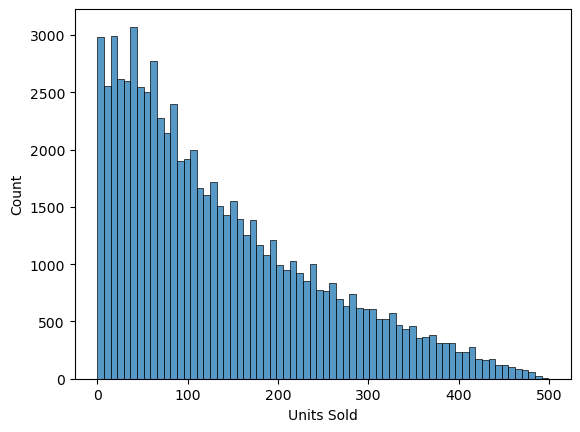

In [30]:
sns.histplot(df,x='Units Sold')

In [31]:
df.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
Different             float64
dtype: object

<Axes: xlabel='Category', ylabel='Units Sold'>

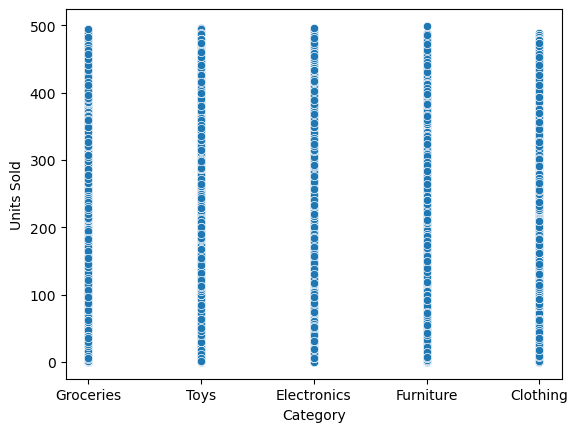

In [32]:
sns.scatterplot(df, x='Category', y='Units Sold')

<Axes: xlabel='Inventory Level', ylabel='Units Sold'>

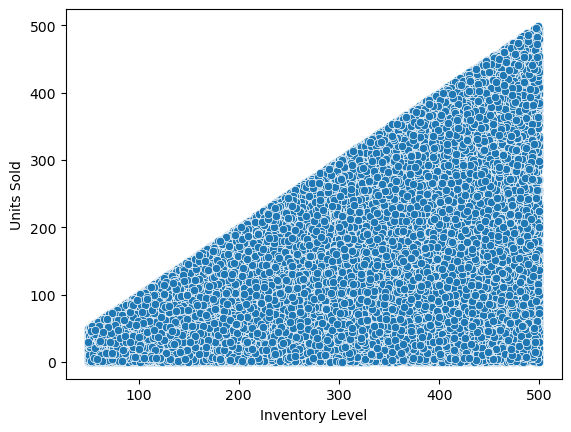

In [33]:
sns.scatterplot(df, x='Inventory Level', y='Units Sold')
#ok this one is highly related 

<Axes: xlabel='Units Ordered', ylabel='Units Sold'>

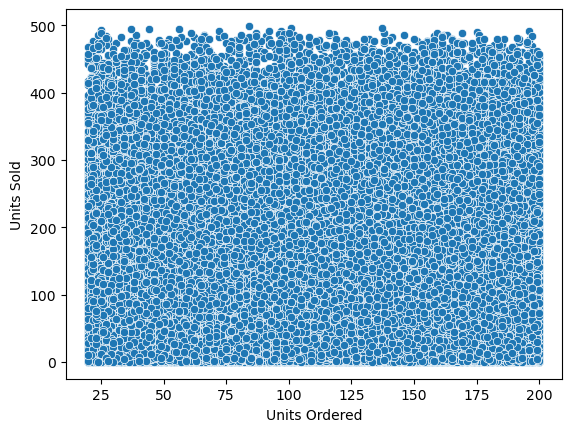

In [34]:
sns.scatterplot(df, x='Units Ordered', y='Units Sold')

<Axes: xlabel='Discount', ylabel='Units Sold'>

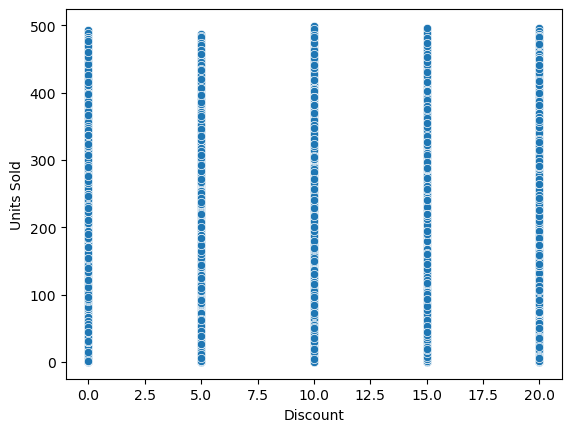

In [35]:
sns.scatterplot(df, x='Discount', y='Units Sold')
#yes u were right , discounts are 0,5,10,15,20

In [36]:
df = df.drop(columns='Different')

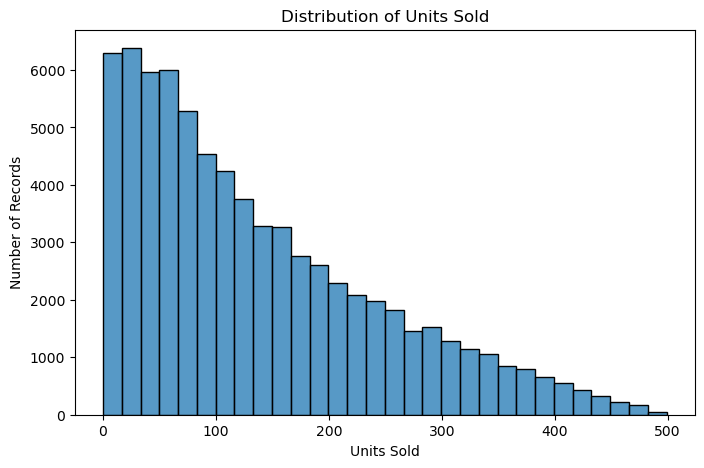

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Units Sold', bins=30)

plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Number of Records')

plt.show()

In [38]:
df.groupby('Category')['Units Sold'].mean()

Category
Clothing       136.685765
Electronics    135.006680
Furniture      137.765630
Groceries      136.916159
Toys           135.934235
Name: Units Sold, dtype: float64

In [39]:
df.head()


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,73.64,0,Sunny,0,68.95,Summer


<Axes: xlabel='Holiday/Promotion', ylabel='Units Sold'>

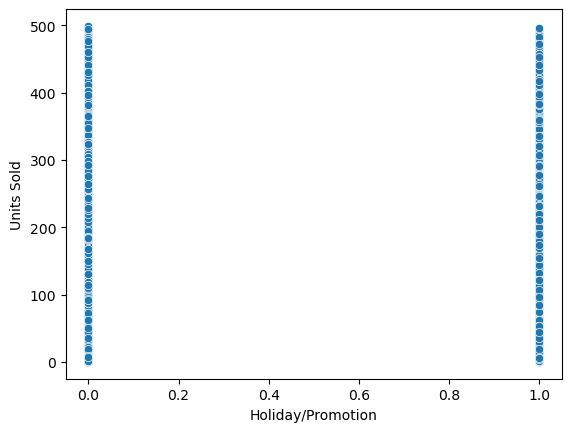

In [40]:
sns.scatterplot(df, x='Holiday/Promotion',y='Units Sold')

<Axes: xlabel='Competitor Pricing', ylabel='Units Sold'>

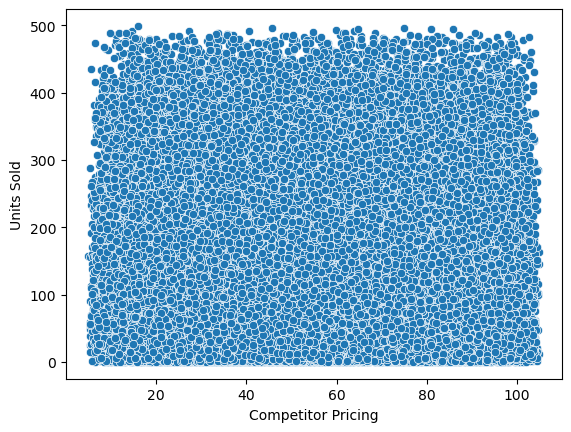

In [41]:
sns.scatterplot(df, x='Competitor Pricing',y='Units Sold')

<Axes: >

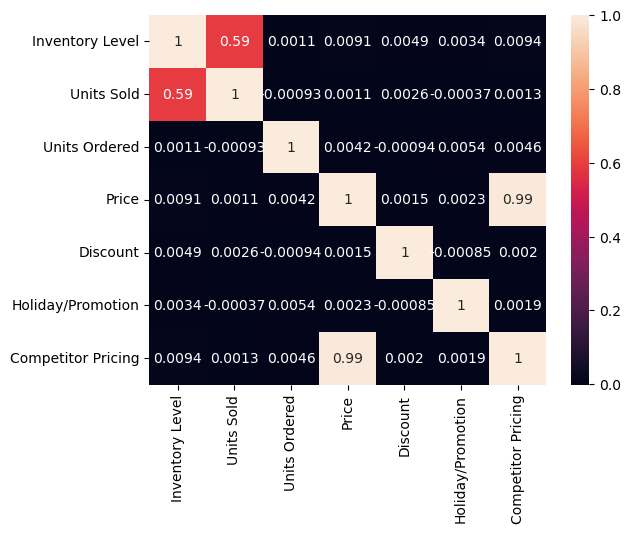

In [42]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [43]:
df.groupby('Discount')['Units Sold'].mean()

Discount
0     135.694585
5     136.567405
10    136.769851
15    136.655293
20    136.640775
Name: Units Sold, dtype: float64

In [44]:
df.groupby('Holiday/Promotion')['Units Sold'].mean()

Holiday/Promotion
0    136.505375
1    136.423926
Name: Units Sold, dtype: float64

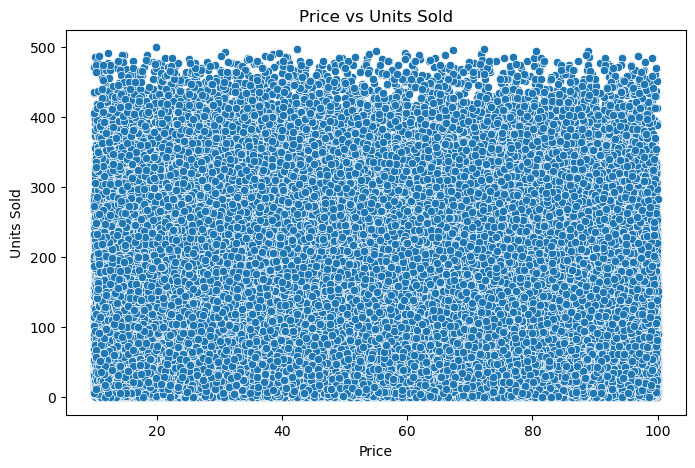

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='Price', y='Units Sold')

plt.title('Price vs Units Sold')
plt.xlabel('Price')
plt.ylabel('Units Sold')

plt.show()

In [46]:
df['Price'].corr(df['Units Sold'])

np.float64(0.0010816075626720165)

In [47]:
df.groupby('Store ID')['Units Sold'].mean()

Store ID
S001    135.140219
S002    135.958618
S003    138.351300
S004    135.379275
S005    137.494938
Name: Units Sold, dtype: float64

In [48]:
df.groupby('Product ID')['Units Sold'].mean().sort_values(ascending=False)

Product ID
P0016    139.116826
P0020    138.907798
P0014    138.884268
P0015    138.791518
P0005    137.796990
P0009    137.369631
P0013    136.968263
P0017    136.938440
P0011    136.624350
P0007    136.613133
P0001    136.268399
P0019    136.224077
P0006    136.013953
P0010    135.832832
P0004    135.567989
P0003    134.960055
P0018    134.760876
P0012    134.519836
P0008    133.669767
P0002    133.468399
Name: Units Sold, dtype: float64

In [49]:
df.groupby('Seasonality')['Units Sold'].mean().sort_values(ascending=False)

Seasonality
Autumn    137.782444
Winter    136.830790
Spring    135.826828
Summer    135.428298
Name: Units Sold, dtype: float64

In [50]:
df.groupby('Weather Condition')['Units Sold'].mean().sort_values(ascending=False)

Weather Condition
Sunny     138.028650
Cloudy    136.758324
Snowy     135.911559
Rainy     135.160028
Name: Units Sold, dtype: float64

In [51]:
df.groupby('Region')['Units Sold'].mean().sort_values(ascending=False)

Region
South    137.060666
East     136.861137
North    136.326860
West     135.605838
Name: Units Sold, dtype: float64

In [52]:
df['Date'] = pd.to_datetime(df['Date'])

In [53]:
df.dtypes

Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition             object
Holiday/Promotion              int64
Competitor Pricing           float64
Seasonality                   object
dtype: object

In [54]:
daily_demand = df.groupby('Date')['Units Sold'].mean()

In [55]:
daily_demand.head()

Date
2022-01-01    144.84
2022-01-02    134.15
2022-01-03    136.81
2022-01-04    140.84
2022-01-05    125.72
Name: Units Sold, dtype: float64

In [56]:
daily_demand.tail()

Date
2023-12-28    162.71
2023-12-29    133.68
2023-12-30    131.56
2023-12-31    112.08
2024-01-01    132.44
Name: Units Sold, dtype: float64

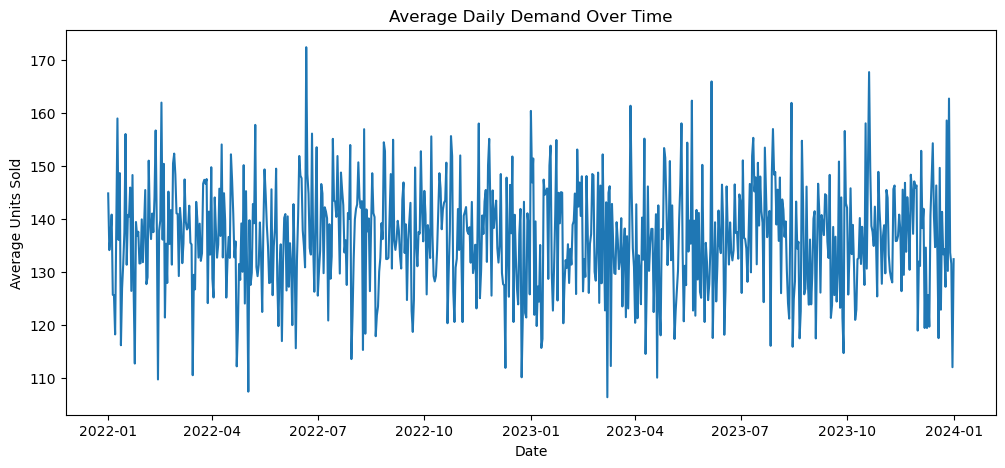

In [57]:
plt.figure(figsize=(12,5))

plt.plot(daily_demand)

plt.title('Average Daily Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Average Units Sold')

plt.show()

In [58]:
monthly_demand = df.groupby(df['Date'].dt.month)['Units Sold'].mean()

In [59]:
monthly_demand

Date
1     135.966667
2     138.610714
3     135.902419
4     134.742833
5     134.430968
6     136.858333
7     139.443065
8     135.712419
9     136.161833
10    137.501452
11    138.443500
12    134.031129
Name: Units Sold, dtype: float64

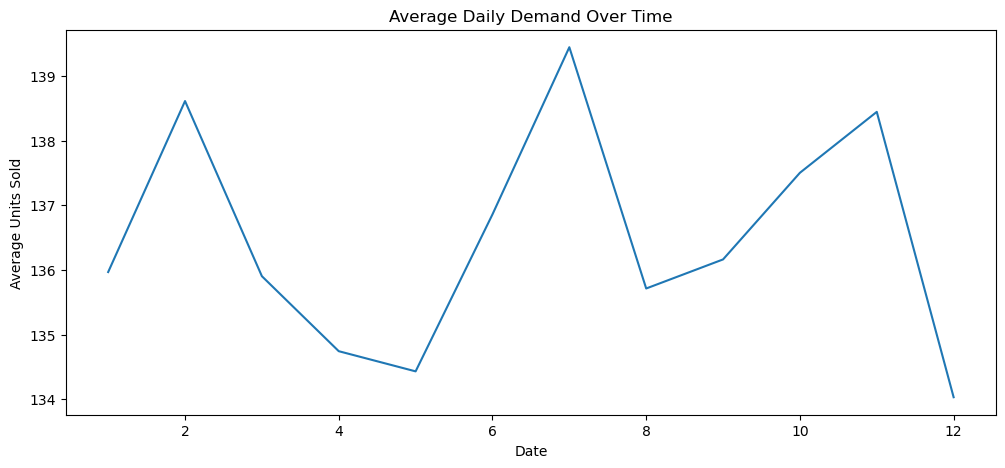

In [60]:
plt.figure(figsize=(12,5))

plt.plot(monthly_demand)

plt.title('Average Daily Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Average Units Sold')

plt.show()

In [61]:
daily_demand_dow = df.groupby(df['Date'].dt.dayofweek)['Units Sold'].mean()

In [62]:
daily_demand_dow

Date
0    135.094667
1    137.307692
2    136.615096
3    137.281923
4    136.851442
5    135.314476
6    136.809714
Name: Units Sold, dtype: float64

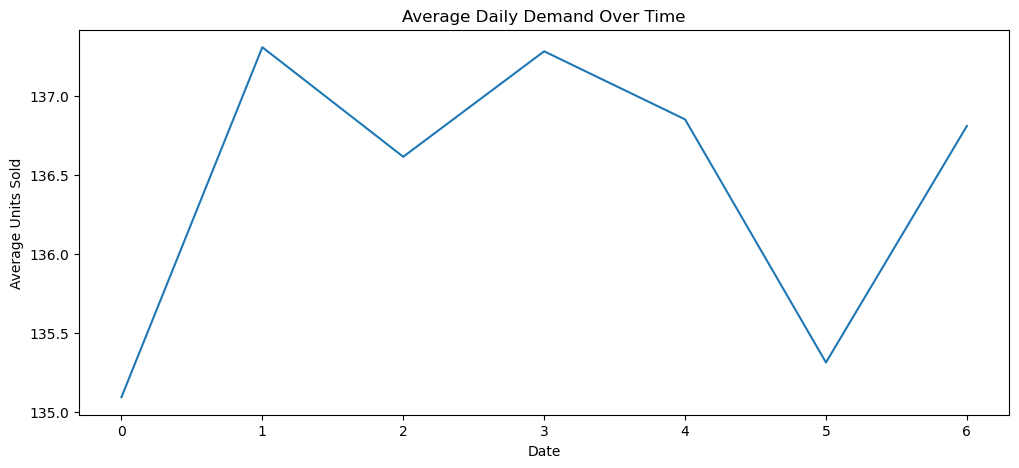

In [63]:
plt.figure(figsize=(12,5))

plt.plot(daily_demand_dow)

plt.title('Average Daily Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Average Units Sold')

plt.show()

In [64]:
daily_demand_dow

Date
0    135.094667
1    137.307692
2    136.615096
3    137.281923
4    136.851442
5    135.314476
6    136.809714
Name: Units Sold, dtype: float64

In [66]:
df = df.sort_values(['Store ID', 'Product ID', 'Date'])

In [67]:
df['Previous Day Sales'] = (
    df.groupby(['Store ID', 'Product ID'])['Units Sold']
      .shift(1)
)

In [68]:
df[['Date', 'Store ID', 'Product ID', 'Units Sold', 'Previous Day Sales']].head(20)

,Date,Store ID,Product ID,Units Sold,Previous Day Sales
0,2022-01-01,S001,P0001,127,NaN
100,2022-01-02,S001,P0001,81,127.0
200,2022-01-03,S001,P0001,5,81.0
300,2022-01-04,S001,P0001,58,5.0
400,2022-01-05,S001,P0001,147,58.0
500,2022-01-06,S001,P0001,37,147.0
600,2022-01-07,S001,P0001,107,37.0
700,2022-01-08,S001,P0001,2,107.0
800,2022-01-09,S001,P0001,350,2.0
900,2022-01-10,S001,P0001,36,350.0


In [69]:
df['Previous Day Sales'].corr(df['Units Sold'])

np.float64(-0.00027678090697735776)

In [70]:
df['Sales 7 Days Ago'] = (
    df.groupby(['Store ID', 'Product ID'])['Units Sold']
      .shift(7)
)

In [71]:
df['Sales 7 Days Ago'].corr(df['Units Sold'])

np.float64(0.0016720940403592984)

In [72]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Previous Day Sales,Sales 7 Days Ago
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn,NaN,NaN
100,2022-01-02,S001,P0001,Groceries,West,116,81,104,27.95,10,Cloudy,0,30.89,Spring,127.0,NaN
200,2022-01-03,S001,P0001,Electronics,West,154,5,189,62.70,20,Rainy,0,58.22,Winter,81.0,NaN
300,2022-01-04,S001,P0001,Groceries,South,85,58,193,77.88,15,Cloudy,1,75.99,Winter,5.0,NaN
400,2022-01-05,S001,P0001,Groceries,South,238,147,37,28.46,20,Sunny,1,29.40,Winter,58.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72699,2023-12-28,S005,P0020,Groceries,South,198,56,27,21.75,5,Sunny,1,25.29,Winter,138.0,160.0
72799,2023-12-29,S005,P0020,Clothing,East,446,268,30,85.58,20,Sunny,1,87.63,Summer,56.0,228.0
72899,2023-12-30,S005,P0020,Toys,North,251,149,181,79.48,10,Cloudy,1,82.69,Autumn,268.0,220.0
72999,2023-12-31,S005,P0020,Furniture,East,64,40,99,90.79,5,Snowy,1,91.67,Winter,149.0,6.0


In [73]:
df = df.drop(columns=['Previous Day Sales', 'Sales 7 Days Ago'])

In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2023-01-01 00:00:00,274.469877,136.464870,110.004473,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,26.021945,7.083746,0.499996,26.191408


In [76]:
y = df['Units Sold']

In [77]:
X = df.drop(columns=['Units Sold'])

In [78]:
df['Year'] = df['Date'].dt.year

In [80]:
df['Month'] = df['Date'].dt.month

In [82]:
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [86]:
df['Weekend'] = df['DayOfWeek'].isin([5,6]).astype(int)

In [87]:
df[['Date', 'DayOfWeek', 'Weekend']].head(10)

,Date,DayOfWeek,Weekend
0,2022-01-01,5,1
100,2022-01-02,6,1
200,2022-01-03,0,0
300,2022-01-04,1,0
400,2022-01-05,2,0
500,2022-01-06,3,0
600,2022-01-07,4,0
700,2022-01-08,5,1
800,2022-01-09,6,1
900,2022-01-10,0,0


In [88]:
y = df['Units Sold']

X = df.drop(columns=['Units Sold'])

In [89]:
df.head(4)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,DatOfWeek,DayOfWeek,Weekend
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn,2022,1,5,5,1
100,2022-01-02,S001,P0001,Groceries,West,116,81,104,27.95,10,Cloudy,0,30.89,Spring,2022,1,6,6,1
200,2022-01-03,S001,P0001,Electronics,West,154,5,189,62.70,20,Rainy,0,58.22,Winter,2022,1,0,0,0
300,2022-01-04,S001,P0001,Groceries,South,85,58,193,77.88,15,Cloudy,1,75.99,Winter,2022,1,1,1,0


In [92]:
from sklearn.model_selection import train_test_split

In [99]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20,  shuffle=False)

In [100]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)


In [101]:
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [102]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(58480, 53)
(14620, 53)


In [103]:
X_train = X_train.drop(columns=['Date'])
X_test = X_test.drop(columns=['Date'])

In [104]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)
print(y_train.shape)
print(y_test.shape)

(58480, 53)
(14620, 53)
(58480,)
(14620,)


In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [106]:
model_lr = LinearRegression()
model_dt = DecisionTreeRegressor()
model_rf = RandomForestRegressor()


In [110]:
X_train_encoded.dtypes

Date                        datetime64[ns]
Inventory Level                      int64
Units Ordered                        int64
Price                              float64
Discount                             int64
Holiday/Promotion                    int64
Competitor Pricing                 float64
Year                                 int32
Month                                int32
DatOfWeek                            int32
DayOfWeek                            int32
Weekend                              int64
Store ID_S001                         bool
Store ID_S002                         bool
Store ID_S003                         bool
Store ID_S004                         bool
Product ID_P0001                      bool
Product ID_P0002                      bool
Product ID_P0003                      bool
Product ID_P0004                      bool
Product ID_P0005                      bool
Product ID_P0006                      bool
Product ID_P0007                      bool
Product ID_

In [112]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

In [120]:
model_lr.fit(X_train_encoded,y_train)
model_dt.fit(X_train_encoded,y_train)
model_rf.fit(X_train_encoded, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [121]:
y_pred_lr = model_lr.predict(X_test_encoded)
y_pred_dt = model_dt.predict(X_test_encoded)
y_pred_rf = model_rf.predict(X_test_encoded)

In [115]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(58480, 52)
(14620, 49)


In [116]:
print(X_train_encoded.dtypes.value_counts())
print(X_test_encoded.dtypes.value_counts())

bool       41
int64       5
int32       4
float64     2
Name: count, dtype: int64
bool       38
int64       5
int32       4
float64     2
Name: count, dtype: int64


In [117]:
print(X_train_encoded.columns.equals(X_test_encoded.columns))

False


In [118]:
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [119]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)
print(X_train_encoded.columns.equals(X_test_encoded.columns))

(58480, 52)
(14620, 52)
True


In [122]:
results = []

models = {
    'LinearRegression' : model_lr,
    'DecisionTree': model_dt,
    'RandomForest' : model_rf
    
}

predictions = {
    'LinearRegression' : y_pred_lr,
    'DecisionTree': y_pred_dt,
    'RandomForest' : y_pred_rf
}

for name, pred in predictions.items(): 
    results.append({
        'model' : name,
        'MAE' : mean_absolute_error(y_test, pred),
        'RSME' : root_mean_squared_error(y_test,pred),
        'R2_score' : r2_score(y_test,pred)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='R2_score', ascending=False )

In [123]:
results_df

,model,MAE,RSME,R2_score
0,LinearRegression,69.051392,88.170527,0.351660
2,RandomForest,69.695930,89.547870,0.331245
1,DecisionTree,93.354172,126.321963,-0.330804


In [127]:
print(y_pred_dt)
print(y_pred_lr)
print(y_pred_rf)

[ 54. 158.  97. ... 198.  49. 105.]
[ 57.10360023 112.62435231  80.79092036 ... 126.76518037  34.162338
  58.99573584]
[ 52.87 121.81  81.08 ... 139.86  37.16  59.78]


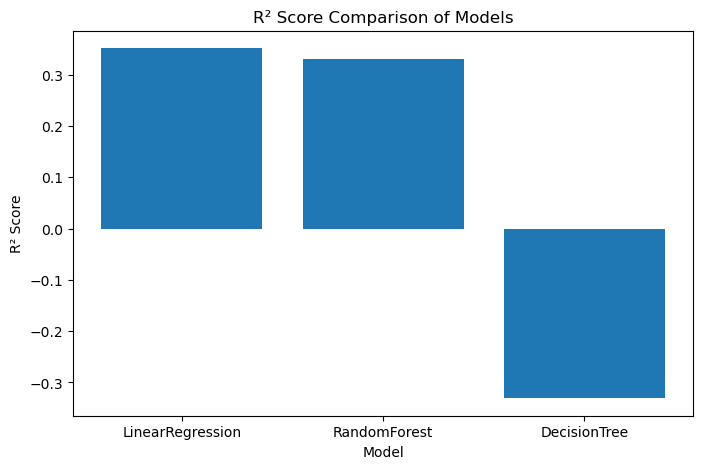

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["model"], results_df["R2_score"])

plt.title("R² Score Comparison of Models")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

In [131]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')

dummy.fit(X_train_encoded, y_train)

y_pred_dummy = dummy.predict(X_test_encoded)

print("Dummy Baseline")
print("MAE:", mean_absolute_error(y_test, y_pred_dummy))
print("RMSE:", root_mean_squared_error(y_test, y_pred_dummy))
print("R²:", r2_score(y_test, y_pred_dummy))

Dummy Baseline
MAE: 89.35453065904883
RMSE: 109.50952734154615
R²: -0.0001382637679843146


In [132]:
feature_importance = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Inventory Level,0.409532
1,Units Ordered,0.079715
5,Competitor Pricing,0.071548
2,Price,0.071171
7,Month,0.043306
3,Discount,0.026424
9,DayOfWeek,0.017108
8,DatOfWeek,0.016874
6,Year,0.009887
4,Holiday/Promotion,0.009809


In [133]:
df = df.drop(columns=['DatOfWeek'])

In [134]:
df['Price Difference'] = df['Price'] - df['Competitor Pricing']

In [135]:
df['Price Ratio'] = df['Price'] / df['Competitor Pricing']

In [136]:
df['Inventory to Order Ratio'] = (
    df['Inventory Level'] / (df['Units Ordered'] + 1)
)

In [137]:
df[['Price', 'Competitor Pricing', 'Price Difference', 'Price Ratio']].head()

,Price,Competitor Pricing,Price Difference,Price Ratio
0,33.50,29.69,3.81,1.128326
100,27.95,30.89,-2.94,0.904824
200,62.70,58.22,4.48,1.076950
300,77.88,75.99,1.89,1.024872
400,28.46,29.40,-0.94,0.968027


In [138]:
import joblib

joblib.dump(model_lr, 'retail_demand_model.pkl')
joblib.dump(
    X_train_encoded.columns.tolist(),
    'model_features.pkl'
)

['model_features.pkl']

In [139]:
import os

print(os.path.exists('retail_demand_model.pkl'))
print(os.path.exists('model_features.pkl'))

True
True


In [140]:
model_features = joblib.load('model_features.pkl')

In [141]:
model_lr = joblib.load('retail_demand_model.pkl')

In [142]:
def predict_demand(
    store_id,
    product_id,
    category,
    region,
    inventory_level,
    units_ordered,
    price,
    discount,
    weather_condition,
    holiday_promotion,
    competitor_pricing,
    seasonality,
    year,
    month,
    day_of_week,
    weekend
):
    
    # Create a DataFrame from the user's input
    input_data = pd.DataFrame({
        'Store ID': [store_id],
        'Product ID': [product_id],
        'Category': [category],
        'Region': [region],
        'Inventory Level': [inventory_level],
        'Units Ordered': [units_ordered],
        'Price': [price],
        'Discount': [discount],
        'Weather Condition': [weather_condition],
        'Holiday/Promotion': [holiday_promotion],
        'Competitor Pricing': [competitor_pricing],
        'Seasonality': [seasonality],
        'Year': [year],
        'Month': [month],
        'DayOfWeek': [day_of_week],
        'Weekend': [weekend],
        
        # Our engineered pricing features
        'Price Difference': [price - competitor_pricing],
        'Price Ratio': [price / competitor_pricing]
    })

    # One-hot encode categorical variables
    input_encoded = pd.get_dummies(input_data)

    # Make sure input has exactly the same columns as training data
    input_encoded = input_encoded.reindex(
        columns=model_features,
        fill_value=0
    )

    # Make sure data type matches the training data
    input_encoded = input_encoded.astype(float)

    # Make prediction
    prediction = model_lr.predict(input_encoded)[0]

    return round(prediction, 2)

In [143]:
prediction = predict_demand(
    store_id='S001',
    product_id='P0001',
    category='Electronics',
    region='North',
    inventory_level=150,
    units_ordered=100,
    price=50,
    discount=10,
    weather_condition='Sunny',
    holiday_promotion=0,
    competitor_pricing=48,
    seasonality='Summer',
    year=2022,
    month=7,
    day_of_week=4,
    weekend=0
)

print("Predicted Units Sold:", prediction)

Predicted Units Sold: 75.29
